# AUDA Batch Benchmark

Compares **Baseline** preprocessing vs **AUDA** preprocessing across 40 real-world datasets,
grouped by shape category.

| Category | Shape rule |
|---|---|
| `small` | < 200 rows |
| `tall` | > 800 rows |
| `wide` | < 200 rows, > 20 cols |
| `wide_tall` | > 800 rows, > 14 cols |

Both pipelines use **the same `RandomForestClassifier`** — only preprocessing differs.

**Run from `auda_datasets/` with the project venv activated.**

In [17]:
import sys, os, json, time, warnings
warnings.filterwarnings('ignore')

REPO_ROOT = os.path.abspath('..')
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

from auto_eda_agent import AUDA, FeatureTransformer
from auto_eda_agent.profiler import DataProfiler

print('Imports OK')
print(f'Repo root: {REPO_ROOT}')

Imports OK
Repo root: c:\Nicholas\Semester 6\BIgData\fp-dustin-1\auto-eda-agent


In [18]:
OUTPUT_DIR   = 'output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

DATASETS_DIR = '../auda_datasets/datasets'
CONFIG_PATH  = os.path.join(DATASETS_DIR, 'config.json')

with open(CONFIG_PATH) as f:
    full_registry = json.load(f)

# ── TEST MODE ─────────────────────────────────────────────────────────────
# True  → run only N datasets per category (fast, for testing)
# False → run all datasets (for final results)
TEST_MODE        = False
DATASETS_PER_CAT = 2

if TEST_MODE:
    seen, registry = {}, []
    for entry in full_registry:
        cat = entry['file'].split('/')[0]
        if seen.get(cat, 0) < DATASETS_PER_CAT:
            registry.append(entry)
            seen[cat] = seen.get(cat, 0) + 1
    print(f'TEST MODE: {len(registry)} datasets ({DATASETS_PER_CAT} per category)')
else:
    registry = full_registry
    print(f'FULL MODE: {len(registry)} datasets')

print(f'Output folder : {os.path.abspath(OUTPUT_DIR)}')
print(f'Datasets root : {os.path.abspath(DATASETS_DIR)}')
pd.DataFrame(registry)[['file', 'target']]

FULL MODE: 39 datasets
Output folder : c:\Nicholas\Semester 6\BIgData\fp-dustin-1\auto-eda-agent\auda_benchmark\output
Datasets root : c:\Nicholas\Semester 6\BIgData\fp-dustin-1\auto-eda-agent\auda_datasets\datasets


,file,target
0,tall/titanic.csv,Survived
1,tall/stroke.csv,stroke
2,tall/weatheraus.csv,RainTomorrow
3,tall/heart_disease.csv,target
4,tall/cardio_disease.csv,cardio
5,tall/diabetes_2023.csv,diabetes
6,tall/churn_modelling.csv,Exited
7,tall/bank_marketing.csv,y
8,tall/adult_census.csv,income
9,tall/obesity_risk.csv,NObeyesdad


In [19]:
# ── LLM Mode (optional) ───────────────────────────────────────────────────
# Set USE_LLM = True and provide a Groq API key to get LLM-powered
# feature recommendations (marked [LLM] in output).
# Get a free key at https://console.groq.com
USE_LLM      = False
GROQ_API_KEY = ''   # or set via GROQ_API_KEY environment variable

if USE_LLM:
    try:
        from auto_eda_agent import GroqProvider
        _llm_provider = GroqProvider(api_key=GROQ_API_KEY or None)
        print('LLM mode: Groq provider loaded — suggestions will include [LLM] items')
    except Exception as _e:
        print(f'LLM mode: failed ({_e}) — falling back to rule-based')
        USE_LLM, _llm_provider = False, None
else:
    _llm_provider = None
    print('LLM mode: disabled (rule-based recommendations only)')


# ── Target encoder ────────────────────────────────────────────────────────
def safe_encode_target(y):
    le = LabelEncoder()
    return pd.Series(le.fit_transform(y.fillna('__nan__').astype(str)), name=y.name)


# ── Categorical encoder (shared by both pipelines) ────────────────────────
def encode_categoricals(X_train, X_test):
    cat_cols = X_train.select_dtypes(exclude='number').columns.tolist()
    num_cols = X_train.select_dtypes(include='number').columns.tolist()
    if not cat_cols:
        return X_train[num_cols].reset_index(drop=True), X_test[num_cols].reset_index(drop=True)
    for col in cat_cols:
        X_train[col] = X_train[col].fillna('Unknown').astype(str)
        X_test[col]  = X_test[col].fillna('Unknown').astype(str)
    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    cat_tr = pd.DataFrame(enc.fit_transform(X_train[cat_cols]), columns=cat_cols)
    cat_te = pd.DataFrame(enc.transform(X_test[cat_cols]),      columns=cat_cols)
    X_tr = pd.concat([X_train[num_cols].reset_index(drop=True), cat_tr], axis=1)
    X_te = pd.concat([X_test[num_cols].reset_index(drop=True),  cat_te], axis=1)
    return X_tr, X_te


# ── Baseline: SimpleImputer(mean) + OrdinalEncoder ────────────────────────
def run_baseline(X_train, X_test):
    X_tr, X_te = X_train.copy(), X_test.copy()
    drop_cols = X_tr.columns[X_tr.isnull().mean() >= 0.6].tolist()
    X_tr = X_tr.drop(columns=drop_cols)
    X_te = X_te.drop(columns=drop_cols, errors='ignore')
    num_cols = X_tr.select_dtypes(include='number').columns.tolist()
    cat_cols = X_tr.select_dtypes(exclude='number').columns.tolist()
    if num_cols:
        imp = SimpleImputer(strategy='mean')
        X_tr[num_cols] = imp.fit_transform(X_tr[num_cols])
        X_te[num_cols] = imp.transform(X_te[num_cols])
    if cat_cols:
        imp = SimpleImputer(strategy='most_frequent')
        X_tr[cat_cols] = imp.fit_transform(X_tr[cat_cols])
        X_te[cat_cols] = imp.transform(X_te[cat_cols])
    return encode_categoricals(X_tr, X_te)


# ── AUDA raw: pipeline + FeatureTransformer + encoding ───────────────────
def _run_auda_raw(X_train, y_train, X_test):
    df_tr = X_train.copy()
    df_tr['__target__'] = y_train.values

    agent = AUDA(df_tr, verbose=False, llm_provider=_llm_provider)
    agent.run_full_pipeline()
    cleaned = agent.cleaned_df_

    X_tr_c = cleaned.drop(columns=['__target__'])
    y_tr_c = cleaned['__target__'].astype(int)

    keep   = [c for c in X_tr_c.columns if c in X_test.columns]
    X_te_c = X_test[keep].copy()

    for col in X_tr_c.select_dtypes(include='number').columns:
        if col in X_te_c.columns and X_te_c[col].isnull().any():
            X_te_c[col] = X_te_c[col].fillna(X_tr_c[col].median())
    for col in X_tr_c.select_dtypes(exclude='number').columns:
        if col in X_te_c.columns and X_te_c[col].isnull().any():
            mode_val = X_tr_c[col].mode()
            X_te_c[col] = X_te_c[col].fillna(mode_val.iloc[0] if len(mode_val) else 'Unknown')

    prof = DataProfiler(X_tr_c)
    prof.detect_column_types()
    ft = FeatureTransformer(
        X_tr_c, profiler=prof,
        skew_threshold=1.0, iqr_k=5.0, scale=False,
        frequency_encode_threshold=20,
    )
    X_tr_t = ft.fit_transform()
    X_te_t = ft.transform(X_te_c)

    X_tr, X_te = encode_categoricals(X_tr_t.copy(), X_te_t.copy())
    return X_tr, y_tr_c, X_te, agent


# ── AUDA Adaptive: skip when baseline is already saturated ────────────────
SATURATION_THRESHOLD = 0.95

def run_auda(X_train, y_train, X_test):
    Xb_tr, Xb_te = run_baseline(X_train.copy(), X_test.copy())
    try:
        n_cls = int(pd.Series(y_train).nunique())
    except Exception:
        n_cls = 2
    scoring = 'roc_auc' if n_cls == 2 else 'roc_auc_ovr'
    try:
        model   = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
        base_cv = cross_val_score(model, Xb_tr, y_train, cv=3, scoring=scoring).mean()
    except Exception:
        base_cv = 0.0
    if base_cv >= SATURATION_THRESHOLD:
        return Xb_tr, y_train, Xb_te, None
    return _run_auda_raw(X_train, y_train, X_test)


# ── Train RF and return metrics ───────────────────────────────────────────
def evaluate(X_train, y_train, X_test, y_test):
    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    n_cls  = len(np.unique(np.concatenate([y_train.values, y_test.values])))
    acc    = accuracy_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred,
                      average='binary' if n_cls == 2 else 'weighted',
                      zero_division=0)
    try:
        if n_cls == 2:
            auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
        else:
            auc = roc_auc_score(y_test, model.predict_proba(X_test),
                                multi_class='ovr', average='macro')
    except Exception:
        auc = float('nan')
    return {'accuracy': acc, 'f1': f1, 'auc': auc, 'n_train': len(X_train)}


# ── Extract AUDA pipeline stats ───────────────────────────────────────────
def extract_stats(agent):
    if agent is None:
        return {
            'rows_before': 0, 'rows_after': 0, 'missing_handled': 0,
            'cols_dropped': 0, 'rows_dropped': 0, 'iqr_outliers': 0,
            'iso_anomalies': 0, 'n_suggestions': 0, 'n_rec_cols': 0,
            'auda_skipped': True,
        }
    s    = {'auda_skipped': False}
    m    = agent.missing_report_ or {}
    smap = m.get('strategy_map', {})
    s['rows_before']     = m.get('rows_before', 0)
    s['rows_after']      = m.get('rows_after', 0)
    s['missing_handled'] = sum(1 for v in smap.values() if v != 'no_action')
    s['cols_dropped']    = sum(1 for v in smap.values() if v == 'drop_column')
    s['rows_dropped']    = s['rows_before'] - s['rows_after']
    a   = agent.anomaly_report_ or {}
    iqr = a.get('iqr', {})
    iso = a.get('isolation_forest', {})
    s['iqr_outliers']  = sum(v.get('n_outliers', 0) for v in iqr.values() if isinstance(v, dict))
    s['iso_anomalies'] = iso.get('n_anomalies', 0) if isinstance(iso, dict) and 'error' not in iso else 0
    fr = agent.feature_report_ or []
    s['n_suggestions'] = sum(len(r.get('suggestions', [])) for r in fr)
    s['n_rec_cols']    = len(fr)
    return s


print('Helper functions ready.')
print(f'LLM mode: {"ON  — Groq provider" if USE_LLM else "OFF — rule-based only"}')

LLM mode: disabled (rule-based recommendations only)
Helper functions ready.
LLM mode: OFF — rule-based only


## Benchmark Loop

Runs all 40 datasets sequentially.
- Datasets with **> 20 000 rows** are randomly sampled to keep runtime manageable.
- Targets with **> 20 unique values** are skipped (regression, not classification).
- Each step is wrapped in `try/except` so one failure never stops the whole run.

> **Expected runtime:** 15–30 minutes depending on machine.

In [20]:
results      = []
feature_recs = []   # one entry per suggestion per column per dataset
TOTAL        = len(registry)

for idx, entry in enumerate(registry, 1):
    fname    = entry['file']
    fp       = os.path.join(DATASETS_DIR, fname)
    tgt      = entry['target']
    category = fname.split('/')[0]
    name     = os.path.basename(fname)
    t0       = time.time()
    row      = {'dataset': name, 'file': fname, 'category': category, 'target': tgt}

    print(f'[{idx:02d}/{TOTAL}] {fname:<50}', end='')

    try:
        # ── Load ──────────────────────────────────────────────────────────
        if not os.path.exists(fp):
            row['status'] = 'missing'
            results.append(row)
            print('SKIP - file not found')
            continue

        df = pd.read_csv(fp, low_memory=False)
        row['n_rows']      = df.shape[0]
        row['n_cols']      = df.shape[1]
        row['n_rows_used'] = len(df)   # full dataset, no cap

        # ── Validate target (case-insensitive fallback) ────────────────────
        col_lower = {c.strip().lower(): c for c in df.columns}
        if tgt not in df.columns:
            if tgt.lower() in col_lower:
                tgt = col_lower[tgt.lower()]
            else:
                row['status'] = 'no_target'
                results.append(row)
                print('SKIP - target not found')
                continue

        X         = df.drop(columns=[tgt])
        y         = df[tgt]
        n_classes = int(y.dropna().nunique())
        row['n_classes'] = n_classes

        if n_classes < 2:
            row['status'] = 'single_class'
            results.append(row)
            print('SKIP - only 1 class')
            continue
        if n_classes > 20:
            row['status'] = 'too_many_classes'
            results.append(row)
            print(f'SKIP - {n_classes} classes (regression?)')
            continue

        y = safe_encode_target(y)

        # ── Train / test split ─────────────────────────────────────────────
        try:
            X_tr, X_te, y_tr, y_te = train_test_split(
                X, y, test_size=0.2, random_state=42, stratify=y)
        except ValueError:
            X_tr, X_te, y_tr, y_te = train_test_split(
                X, y, test_size=0.2, random_state=42)

        # ── Baseline ──────────────────────────────────────────────────────
        try:
            Xb_tr, Xb_te = run_baseline(X_tr.copy(), X_te.copy())
            mb = evaluate(Xb_tr, y_tr, Xb_te, y_te)
            row['base_acc']     = mb['accuracy']
            row['base_f1']      = mb['f1']
            row['base_auc']     = mb['auc']
            row['base_n_train'] = mb['n_train']
        except Exception as e:
            row['base_acc'] = row['base_f1'] = row['base_auc'] = row['base_n_train'] = np.nan
            row['err_baseline'] = str(e)[:120]

        # ── AUDA ──────────────────────────────────────────────────────────
        try:
            Xa_tr, ya_tr, Xa_te, agent = run_auda(X_tr.copy(), y_tr.copy(), X_te.copy())
            ma = evaluate(Xa_tr, ya_tr, Xa_te, y_te)
            row['auda_acc']     = ma['accuracy']
            row['auda_f1']      = ma['f1']
            row['auda_auc']     = ma['auc']
            row['auda_n_train'] = ma['n_train']
            row.update(extract_stats(agent))

            # Collect per-column feature recommendations
            if agent is not None:
                for rec in (agent.feature_report_ or []):
                    for sug in rec.get('suggestions', []):
                        is_llm = sug.startswith('[LLM] ')
                        feature_recs.append({
                            'dataset':    name,
                            'category':   category,
                            'column':     rec['column'],
                            'col_type':   rec['type'],
                            'suggestion': sug[6:] if is_llm else sug,
                            'source':     'LLM' if is_llm else 'rule',
                        })
        except Exception as e:
            row['auda_acc'] = row['auda_f1'] = row['auda_auc'] = row['auda_n_train'] = np.nan
            row['err_auda'] = str(e)[:120]

        # ── Deltas ────────────────────────────────────────────────────────
        row['delta_acc'] = row.get('auda_acc', np.nan) - row.get('base_acc', np.nan)
        row['delta_f1']  = row.get('auda_f1',  np.nan) - row.get('base_f1',  np.nan)
        row['delta_auc'] = row.get('auda_auc', np.nan) - row.get('base_auc', np.nan)
        row['status']    = 'ok'

        b_auc   = row.get('base_auc', 0) or 0
        a_auc   = row.get('auda_auc', 0) or 0
        d       = row.get('delta_auc', 0) or 0
        elapsed = round(time.time() - t0, 1)
        icon    = 'UP' if d >= 0 else 'DOWN'
        print(f'AUC {b_auc:.4f}->{a_auc:.4f}  d{d:+.4f}  {elapsed}s  [{icon}]')

    except Exception as e:
        row['status'] = 'error'
        row['error']  = str(e)[:200]
        print(f'ERROR: {e}')

    row['elapsed_s'] = round(time.time() - t0, 1)
    results.append(row)

n_ok = sum(1 for r in results if r.get('status') == 'ok')
sep  = '=' * 60
print(f'\n{sep}')
print(f'Completed             : {n_ok}/{len(results)} successful')
print(f'Feature recs collected: {len(feature_recs)}')

[01/39] tall/titanic.csv                                  AUC 0.8290->0.8437  d+0.0147  0.7s  [UP]
[02/39] tall/stroke.csv                                   AUC 0.7725->0.7759  d+0.0034  0.9s  [UP]
[03/39] tall/weatheraus.csv                               AUC 0.8914->0.8223  d-0.0692  11.5s  [DOWN]
[04/39] tall/heart_disease.csv                            AUC 1.0000->1.0000  d+0.0000  0.6s  [UP]
[05/39] tall/cardio_disease.csv                           AUC 0.7825->0.7828  d+0.0004  3.4s  [UP]
[06/39] tall/diabetes_2023.csv                            AUC 0.9624->0.9624  d-0.0000  2.3s  [DOWN]
[07/39] tall/churn_modelling.csv                          AUC 0.8373->0.8489  d+0.0116  1.2s  [UP]
[08/39] tall/bank_marketing.csv                           AUC 0.7868->0.7868  d+0.0000  2.5s  [UP]
[09/39] tall/adult_census.csv                             AUC 0.9041->0.9037  d-0.0004  1.9s  [DOWN]
[10/39] tall/obesity_risk.csv                             AUC 0.9968->0.9968  d+0.0000  0.7s  [UP]
[11

In [21]:
df_res = pd.DataFrame(results)
df_ok  = df_res[df_res['status'] == 'ok'].copy()

not_ok = df_res[df_res['status'] != 'ok'][['dataset', 'category', 'status']]
if len(not_ok):
    print('Non-successful entries:')
    print(not_ok.to_string(index=False))
else:
    print('All entries ran successfully!')

print(f'\n{len(df_ok)} datasets in results.')

Non-successful entries:
     dataset category       status
   sonar.csv    small single_class
banknote.csv    small single_class

37 datasets in results.


## Results Table
Colour gradient on `delta_auc`: green = AUDA improved, red = AUDA degraded.

In [22]:
from IPython.display import display

display_cols = [
    'dataset', 'category', 'n_rows_used', 'n_cols', 'n_classes',
    'base_auc', 'auda_auc', 'delta_auc', 'delta_f1', 'elapsed_s'
]

styled = (
    df_ok[display_cols]
    .sort_values(['category', 'dataset'])
    .style
    .format({
        'base_auc':    '{:.4f}',
        'auda_auc':    '{:.4f}',
        'delta_auc':   '{:+.4f}',
        'delta_f1':    '{:+.4f}',
        'elapsed_s':   '{:.0f}s',
        'n_rows_used': '{:,}',
    })
    .background_gradient(subset=['delta_auc'], cmap='RdYlGn', vmin=-0.05, vmax=0.05)
    .set_caption('Benchmark Results — Baseline vs AUDA')
)
display(styled)

,dataset,category,n_rows_used,n_cols,n_classes,base_auc,auda_auc,delta_auc,delta_f1,elapsed_s
27,blood_transfusion.csv,small,199,12,2,0.8626,0.8324,-0.0302,+0.1407,1s
25,ecoli.csv,small,199,9,3,nan,nan,+nan,-0.2225,1s
21,haberman.csv,small,199,4,2,0.7962,0.7962,+0.0000,+0.0000,1s
22,heart_cleveland.csv,small,199,9,2,0.8787,0.8773,-0.0013,+0.0000,1s
20,iris.csv,small,150,6,3,1.0000,1.0000,+0.0000,+0.0000,1s
28,liver_patient.csv,small,199,11,2,0.6517,0.6967,+0.0450,+0.0000,1s
24,vertebral.csv,small,199,7,2,0.9970,0.9970,+0.0000,+0.0000,1s
8,adult_census.csv,tall,"32,561",15,2,0.9041,0.9037,-0.0004,-0.0002,2s
7,bank_marketing.csv,tall,"41,188",20,2,0.7868,0.7868,+0.0000,+0.0000,2s
4,cardio_disease.csv,tall,"70,000",13,2,0.7825,0.7828,+0.0004,-0.0006,3s


## Summary by Category

In [23]:
def win_rate(x):
    pct = (x > 0).mean() * 100
    return f'{pct:.0f}%'

agg_map = {
    'n_datasets':       ('dataset',        'count'),
    'mean_base_auc':    ('base_auc',       'mean'),
    'mean_auda_auc':    ('auda_auc',       'mean'),
    'mean_delta_auc':   ('delta_auc',      'mean'),
    'mean_base_acc':    ('base_acc',       'mean'),
    'mean_auda_acc':    ('auda_acc',       'mean'),
    'mean_delta_acc':   ('delta_acc',      'mean'),
    'mean_delta_f1':    ('delta_f1',       'mean'),
    'auda_wins':        ('delta_auc',      lambda x: int((x > 0).sum())),
    'win_rate':         ('delta_auc',      win_rate),
    'mean_missing':     ('missing_handled','mean'),
    'mean_outliers':    ('iqr_outliers',   'mean'),
    'mean_suggestions': ('n_suggestions',  'mean'),
    'total_elapsed_s':  ('elapsed_s',      'sum'),
}

summary = df_ok.groupby('category').agg(**agg_map).reset_index()
for col in ['mean_base_auc', 'mean_auda_auc', 'mean_delta_auc',
            'mean_base_acc', 'mean_auda_acc', 'mean_delta_acc', 'mean_delta_f1']:
    summary[col] = summary[col].round(4)
for col in ['mean_missing', 'mean_outliers', 'mean_suggestions']:
    if col in summary.columns:
        summary[col] = summary[col].round(1)

sep = '=' * 100
print(sep)
print('  SUMMARY BY CATEGORY')
print(sep)
print(summary.to_string(index=False))

overall_win   = (df_ok['delta_auc'] > 0).mean() * 100
mean_delta    = df_ok['delta_auc'].mean()
total_elapsed = df_ok['elapsed_s'].sum()
print(f'\nOverall AUDA win rate : {overall_win:.0f}%')
print(f'Overall mean delta AUC: {mean_delta:+.4f}')
print(f'Overall mean delta ACC: {df_ok["delta_acc"].mean():+.4f}')
print(f'Total runtime         : {total_elapsed:.0f}s ({total_elapsed/60:.1f} min)')

# ── Top & worst performer per category ────────────────────────────────────
print(f'\n{sep}')
print('  TOP & WORST PERFORMER PER CATEGORY  (ranked by delta_auc)')
print(sep)

top_cols = ['dataset', 'n_rows', 'n_cols', 'base_auc', 'auda_auc', 'delta_auc']
for cat in sorted(df_ok['category'].unique()):
    sub   = df_ok[df_ok['category'] == cat].copy()
    best  = sub.loc[sub['delta_auc'].idxmax()]
    worst = sub.loc[sub['delta_auc'].idxmin()]
    print(f'\n  [{cat.upper()}]  ({len(sub)} datasets)')
    print(f'  BEST  : {best["dataset"]:<35}  '
          f'delta_auc={best["delta_auc"]:+.4f}  '
          f'(base={best["base_auc"]:.4f} → auda={best["auda_auc"]:.4f})')
    print(f'  WORST : {worst["dataset"]:<35}  '
          f'delta_auc={worst["delta_auc"]:+.4f}  '
          f'(base={worst["base_auc"]:.4f} → auda={worst["auda_auc"]:.4f})')

  SUMMARY BY CATEGORY
 category  n_datasets  mean_base_auc  mean_auda_auc  mean_delta_auc  mean_base_acc  mean_auda_acc  mean_delta_acc  mean_delta_f1  auda_wins win_rate  mean_missing  mean_outliers  mean_suggestions  total_elapsed_s
    small           7         0.8644         0.8666          0.0022         0.8143         0.8143          0.0000        -0.0117          1      14%           0.4           29.9              18.4              8.1
     tall          10         0.8763         0.8723         -0.0039         0.8839         0.8851          0.0012        -0.0046          5      50%           2.4        16610.6              32.3             25.7
     wide          10         0.8429         0.8619          0.0190         0.8046         0.8371          0.0325         0.0406          2      20%           0.0          387.2             165.5             12.2
wide_tall          10         0.9010         0.9002         -0.0008         0.9030         0.9040          0.0010         0.00

## Visualisations

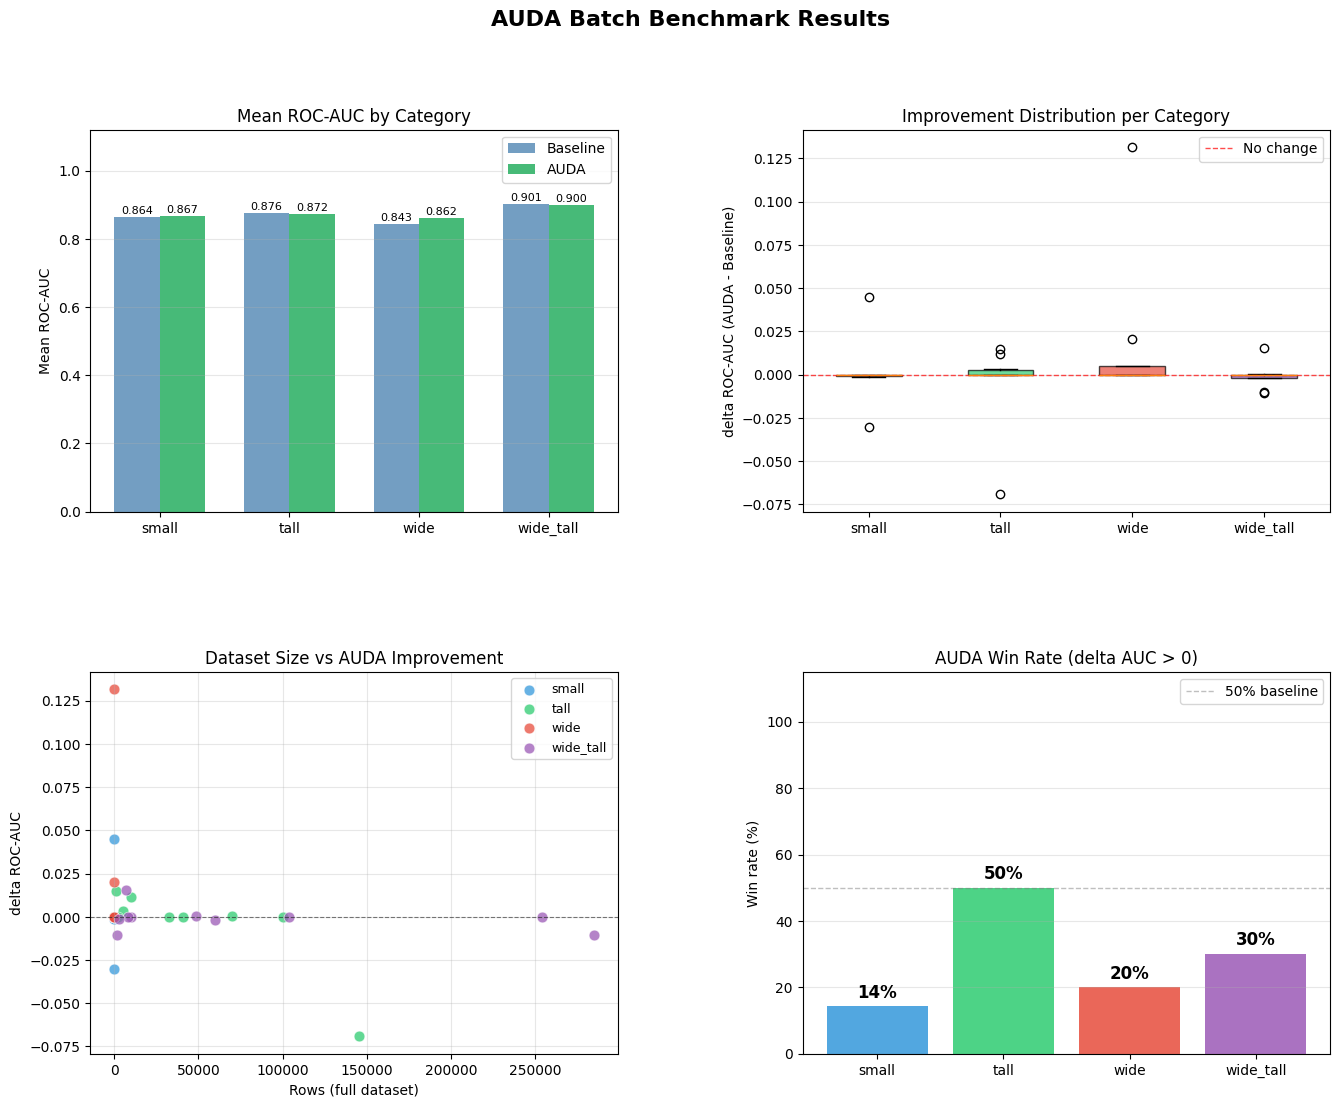

Chart saved → output\benchmark_results.png


In [24]:
CAT_ORDER  = ['small', 'tall', 'wide', 'wide_tall']
CAT_COLORS = {'small': '#3498DB', 'tall': '#2ECC71', 'wide': '#E74C3C', 'wide_tall': '#9B59B6'}
CATS       = [c for c in CAT_ORDER if c in df_ok['category'].values]

fig = plt.figure(figsize=(16, 12))
fig.suptitle('AUDA Batch Benchmark Results', fontsize=16, fontweight='bold')
gs  = gridspec.GridSpec(2, 2, hspace=0.42, wspace=0.35)

# ── Chart 1: Mean ROC-AUC grouped bar per category ────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
x, w = np.arange(len(CATS)), 0.35
mean_base = [df_ok[df_ok['category'] == c]['base_auc'].mean() for c in CATS]
mean_auda = [df_ok[df_ok['category'] == c]['auda_auc'].mean() for c in CATS]
b1 = ax1.bar(x - w/2, mean_base, w, label='Baseline', color='#5B8DB8', alpha=0.85)
b2 = ax1.bar(x + w/2, mean_auda, w, label='AUDA',     color='#27AE60', alpha=0.85)
for bar in list(b1) + list(b2):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
ax1.set_xticks(x); ax1.set_xticklabels(CATS, fontsize=10)
ax1.set_ylim(0, 1.12); ax1.set_ylabel('Mean ROC-AUC')
ax1.set_title('Mean ROC-AUC by Category'); ax1.legend(); ax1.grid(axis='y', alpha=0.3)

# ── Chart 2: Delta ROC-AUC boxplot per category ───────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
data_by_cat = [df_ok[df_ok['category'] == c]['delta_auc'].dropna().values for c in CATS]
bp = ax2.boxplot(data_by_cat, labels=CATS, patch_artist=True, widths=0.5)
for patch, cat in zip(bp['boxes'], CATS):
    patch.set_facecolor(CAT_COLORS.get(cat, '#999'))
    patch.set_alpha(0.7)
ax2.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7, label='No change')
ax2.set_ylabel('delta ROC-AUC (AUDA - Baseline)')
ax2.set_title('Improvement Distribution per Category')
ax2.legend(); ax2.grid(axis='y', alpha=0.3)

# ── Chart 3: Scatter — dataset size vs delta_auc ──────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
for cat in CATS:
    sub = df_ok[df_ok['category'] == cat]
    ax3.scatter(sub['n_rows_used'], sub['delta_auc'],
                label=cat, color=CAT_COLORS.get(cat, '#999'),
                alpha=0.75, s=60, edgecolors='white', linewidths=0.5)
ax3.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax3.set_xlabel('Rows (full dataset)')
ax3.set_ylabel('delta ROC-AUC')
ax3.set_title('Dataset Size vs AUDA Improvement')
ax3.legend(fontsize=9); ax3.grid(alpha=0.3)

# ── Chart 4: Win rate per category ────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
win_rates  = [(df_ok[df_ok['category'] == c]['delta_auc'] > 0).mean() * 100 for c in CATS]
colors4    = [CAT_COLORS.get(c, '#999') for c in CATS]
bars4      = ax4.bar(CATS, win_rates, color=colors4, alpha=0.85)
for bar, v in zip(bars4, win_rates):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{v:.0f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax4.axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='50% baseline')
ax4.set_ylim(0, 115); ax4.set_ylabel('Win rate (%)')
ax4.set_title('AUDA Win Rate (delta AUC > 0)')
ax4.legend(); ax4.grid(axis='y', alpha=0.3)

out_png = os.path.join(OUTPUT_DIR, 'benchmark_results.png')
plt.tight_layout()
plt.savefig(out_png, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved → {out_png}')

## Top / Bottom Performers & AUDA Pipeline Stats

In [25]:
top_cols = ['dataset', 'category', 'n_rows', 'n_cols', 'base_auc', 'auda_auc', 'delta_auc',
            'missing_handled', 'cols_dropped', 'rows_dropped', 'n_suggestions']

print('Top 5 datasets where AUDA improved most:')
print(df_ok.nlargest(5, 'delta_auc')[top_cols].to_string(index=False))

print('\nTop 5 datasets where AUDA degraded most:')
print(df_ok.nsmallest(5, 'delta_auc')[top_cols].to_string(index=False))

# AUDA pipeline statistics per category
stat_cols = ['missing_handled', 'cols_dropped', 'rows_dropped',
             'iqr_outliers', 'iso_anomalies', 'n_suggestions', 'n_rec_cols']
avail = [c for c in stat_cols if c in df_ok.columns]

sep = '=' * 80
print(f'\n{sep}')
print('  AUDA PIPELINE STATS (mean per dataset, by category)')
print(sep)
if avail:
    pipeline_summary = df_ok.groupby('category')[avail].mean().round(1)
    print(pipeline_summary.to_string())

print(f'\n{sep}')
print('  AUDA PIPELINE TOTALS (across all datasets)')
print(sep)
totals = df_ok[avail].sum()
for k, v in totals.items():
    print(f'  {k:<25}: {int(v):,}')

Top 5 datasets where AUDA improved most:
          dataset  category  n_rows  n_cols  base_auc  auda_auc  delta_auc  missing_handled  cols_dropped  rows_dropped  n_suggestions
   sonar_wide.csv      wide     100      61  0.736842  0.868421   0.131579              0.0           0.0           0.0          257.0
liver_patient.csv     small     199      11  0.651667  0.696667   0.045000              0.0           0.0           0.0           39.0
      eeg_eye.csv      wide     199     180  0.706673  0.727036   0.020363              0.0           0.0           0.0          936.0
  telco_churn.csv wide_tall    7043      21  0.803057  0.818594   0.015536              0.0           0.0           0.0           46.0
      titanic.csv      tall     891      12  0.828986  0.843676   0.014690              3.0           1.0           2.0           30.0

Top 5 datasets where AUDA degraded most:
               dataset  category  n_rows  n_cols  base_auc  auda_auc  delta_auc  missing_handled  cols_drop

## Feature Recommendations

AUDA generates per-column feature engineering suggestions for every dataset.
- **source = rule** → generated by built-in rules (always available)
- **source = LLM**  → generated by Groq LLM (only when `USE_LLM = True`)

In [26]:
from IPython.display import display

df_recs = pd.DataFrame(feature_recs)

if df_recs.empty:
    print('No feature recommendations collected (run the benchmark loop first).')
else:
    print(f'Total suggestions : {len(df_recs):,}')
    print(f'Unique datasets   : {df_recs["dataset"].nunique()}')
    print(f'Unique columns    : {df_recs["column"].nunique()}')
    if 'source' in df_recs.columns:
        print(f'LLM suggestions   : {(df_recs["source"] == "LLM").sum():,}')
        print(f'Rule suggestions  : {(df_recs["source"] == "rule").sum():,}')

    # Summary: suggestion count per column type
    print('\nSuggestions by column type:')
    print(df_recs.groupby('col_type').size().sort_values(ascending=False).to_string())

    # Preview: first 30 rows
    print('\nSample (first 30 rows):')
    display(df_recs.head(30))

Total suggestions : 2,554
Unique datasets   : 25
Unique columns    : 625
LLM suggestions   : 0
Rule suggestions  : 2,554

Suggestions by column type:
col_type
numeric        2019
categorical     433
boolean          84
datetime         18

Sample (first 30 rows):


,dataset,category,column,col_type,suggestion,source
0,titanic.csv,tall,PassengerId,numeric,Bin 'PassengerId' into quantile-based buckets ...,rule
1,titanic.csv,tall,PassengerId,numeric,Bin 'PassengerId' into equal-width buckets -> ...,rule
2,titanic.csv,tall,PassengerId,numeric,Consider polynomial features or interactions w...,rule
3,titanic.csv,tall,Pclass,numeric,Consider polynomial features or interactions w...,rule
4,titanic.csv,tall,Name,categorical,Target encode 'Name' (high cardinality: nuniqu...,rule
5,titanic.csv,tall,Name,categorical,Frequency/count encode 'Name' -> 'Name_freq',rule
6,titanic.csv,tall,Name,categorical,Hash encode 'Name' for memory-efficient repres...,rule
7,titanic.csv,tall,Sex,categorical,One-hot encode 'Sex' (nunique=2 <= 10),rule
8,titanic.csv,tall,Sex,categorical,Ordinal encode 'Sex' if natural ordering exists,rule
9,titanic.csv,tall,Age,numeric,Bin 'Age' into quantile-based buckets -> 'Age_...,rule


In [27]:
# ── 1. Clean results summary (key columns only, rounded) ─────────────────
clean_cols = [
    'dataset', 'category', 'n_rows', 'n_cols', 'n_classes',
    'base_acc', 'base_f1', 'base_auc',
    'auda_acc', 'auda_f1', 'auda_auc',
    'delta_acc', 'delta_f1', 'delta_auc',
    'missing_handled', 'cols_dropped', 'rows_dropped',
    'iqr_outliers', 'iso_anomalies', 'n_suggestions', 'n_rec_cols',
    'elapsed_s', 'status',
]
avail_clean = [c for c in clean_cols if c in df_ok.columns]
df_clean = df_ok[avail_clean].copy()
for col in ['base_acc', 'base_f1', 'base_auc', 'auda_acc', 'auda_f1', 'auda_auc',
            'delta_acc', 'delta_f1', 'delta_auc']:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].round(4)

path_summary = os.path.join(OUTPUT_DIR, 'results_summary.csv')
df_clean.to_csv(path_summary, index=False)
print(f'Saved → {path_summary}  ({len(df_clean)} rows, {len(df_clean.columns)} cols)')

# ── 2. Category summary table ─────────────────────────────────────────────
path_cat = os.path.join(OUTPUT_DIR, 'results_by_category.csv')
summary.to_csv(path_cat, index=False)
print(f'Saved → {path_cat}')

# ── 3. Feature recommendations (one row per suggestion) ──────────────────
if feature_recs:
    df_recs_out = pd.DataFrame(feature_recs)
    path_recs = os.path.join(OUTPUT_DIR, 'feature_recommendations.csv')
    df_recs_out.to_csv(path_recs, index=False)
    print(f'Saved → {path_recs}  ({len(df_recs_out):,} suggestions)')
else:
    print('No feature recommendations to save.')

# ── 4. Full raw results (all datasets including skipped) ──────────────────
path_all = os.path.join(OUTPUT_DIR, 'results_all_raw.csv')
df_res.to_csv(path_all, index=False)
print(f'Saved → {path_all}  ({len(df_res)} rows — includes skipped/errored)')

print(f'\nAll outputs in: {os.path.abspath(OUTPUT_DIR)}/')

Saved → output\results_summary.csv  (37 rows, 23 cols)
Saved → output\results_by_category.csv
Saved → output\feature_recommendations.csv  (2,554 suggestions)
Saved → output\results_all_raw.csv  (39 rows — includes skipped/errored)

All outputs in: c:\Nicholas\Semester 6\BIgData\fp-dustin-1\auto-eda-agent\auda_benchmark\output/
